# 2. Image segmentation to accurately delineate the regions of interest(U-net)

## This code mainly implements segmentation prediction of orignal images using a pre-trained U-Net model (based on EfficientNet-B3 encoder).

### Data loading and pre-processing

In [13]:
# Batch read data, fixed seed 24, divide dataset according to 80%
import os
from PIL import Image
import random

random.seed(24)

original_base_dir = '../../EMDS-6/EMDS5-Original'

gt_base_dir = '../../EMDS-6/EMDS5-Ground Truth'

data = []

subfolders = sorted(os.listdir(original_base_dir))

for folder in subfolders:
    original_folder = os.path.join(original_base_dir, folder)
    gt_folder = os.path.join(gt_base_dir, folder)
    if not os.path.isdir(original_folder) or not os.path.isdir(gt_folder):
        continue
    file_list = sorted([f for f in os.listdir(original_folder) if f.lower().endswith('.png')])
    for filename in file_list:
        orig_path = os.path.join(original_folder, filename)
        gt_filename = filename.replace(".png", "-GTM.png")
        gt_path = os.path.join(gt_folder, gt_filename)
        try:
            original_image = Image.open(orig_path).convert("RGB")
            gt_image = Image.open(gt_path).convert("L")
            data.append((original_image, gt_image))
        except Exception as e:
            print(f"{filename} error：", e)

print("Total image:", len(data))

random.shuffle(data)
train_ratio = 0.8
split_index = int(len(data) * train_ratio)
train_data = data[:split_index]
test_data = data[split_index:]

print("Train:", len(train_data))
print("Test:", len(test_data))

Total image: 840
Train: 672
Test: 168


In [192]:
# Data Retention
import pickle

with open("train_data.pkl", "wb") as f:
    pickle.dump(train_data, f)
with open("test_data.pkl", "wb") as f:
    pickle.dump(test_data, f)

### Model definition and training

In [193]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

with open("train_data.pkl", "rb") as f:
    train_data = pickle.load(f)

to_tensor_resize = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

train_data_tensor = [(to_tensor_resize(img), to_tensor_resize(mask)) for img, mask in train_data]
train_loader = DataLoader(train_data_tensor, batch_size=4, shuffle=True)
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    avg_loss = total_loss / len(train_data_tensor)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "model-original.pth")
print("Model save as model-original.pth")


Epoch 1/100, Loss: 0.1950
Epoch 2/100, Loss: 0.1156
Epoch 3/100, Loss: 0.0968
Epoch 4/100, Loss: 0.0827
Epoch 5/100, Loss: 0.0783
Epoch 6/100, Loss: 0.0621
Epoch 7/100, Loss: 0.0611
Epoch 8/100, Loss: 0.0598
Epoch 9/100, Loss: 0.0545
Epoch 10/100, Loss: 0.0530
Epoch 11/100, Loss: 0.0602
Epoch 12/100, Loss: 0.0552
Epoch 13/100, Loss: 0.0805
Epoch 14/100, Loss: 0.0589
Epoch 15/100, Loss: 0.0491
Epoch 16/100, Loss: 0.0444
Epoch 17/100, Loss: 0.0427
Epoch 18/100, Loss: 0.0426
Epoch 19/100, Loss: 0.0500
Epoch 20/100, Loss: 0.0572
Epoch 21/100, Loss: 0.0591
Epoch 22/100, Loss: 0.0473
Epoch 23/100, Loss: 0.0421
Epoch 24/100, Loss: 0.0399
Epoch 25/100, Loss: 0.0392
Epoch 26/100, Loss: 0.0380
Epoch 27/100, Loss: 0.0367
Epoch 28/100, Loss: 0.0359
Epoch 29/100, Loss: 0.0343
Epoch 30/100, Loss: 0.0345
Epoch 31/100, Loss: 0.0343
Epoch 32/100, Loss: 0.0338
Epoch 33/100, Loss: 0.0332
Epoch 34/100, Loss: 0.0332
Epoch 35/100, Loss: 0.0338
Epoch 36/100, Loss: 0.0326
Epoch 37/100, Loss: 0.0948
Epoch 38/1

### Model Evaluation

In [33]:
import segmentation_models_pytorch as smp
import torch.nn.functional as F
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

with open("test_data.pkl", "rb") as f:
    test_data = pickle.load(f)


to_tensor_resize = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

test_data_tensor = [(to_tensor_resize(img), to_tensor_resize(mask)) for img, mask in test_data]
test_loader = DataLoader(test_data_tensor, batch_size=4, shuffle=False)

model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = model.to(device)

# Evaluate models on test sets
model.load_state_dict(torch.load("model-original.pth", weights_only=True))
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        # Forward propagation to obtain predictions
        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds_bin = (preds > 0.5).float()
        # Keep predictions and real labels
        all_preds.append(preds_bin.cpu())
        all_labels.append(masks.cpu())

# Merge the results of all batches
all_preds = torch.cat(all_preds, dim=0)
all_labels = torch.cat(all_labels, dim=0)

### Visualization of model evaluation

Average IoU: 84.92%
Lowest IoU: 32.86%
Highest IoU: 98.66%


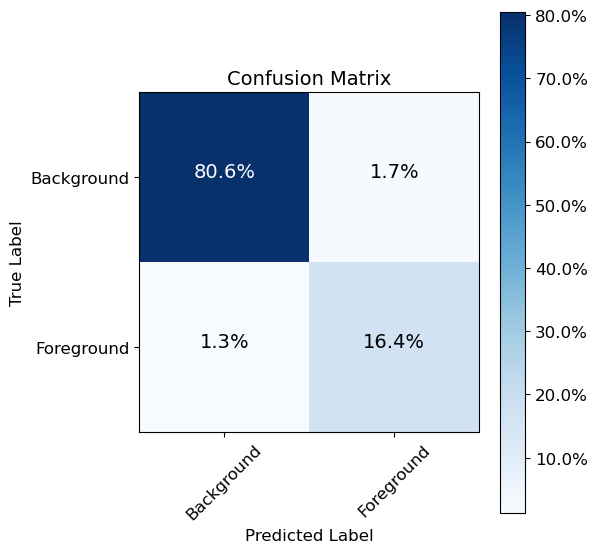

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools

# Flatten predictions and true labels into one-dimensional arrays
all_preds_flat = all_preds.view(-1).numpy().astype(int)
all_labels_flat = all_labels.view(-1).numpy().astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(all_labels_flat, all_preds_flat, labels=[0, 1])

# Calculation of IoU (intersection and integration ratio) metrics
iou_list = []
for i in range(all_preds.shape[0]):
    pred = all_preds[i]
    label = all_labels[i]
    intersection = (pred * label).sum().item()
    union = pred.sum().item() + label.sum().item() - intersection + 1e-6
    iou = intersection / union
    iou_list.append(iou)
# Calculate IoU statistics metrics
iou_list = np.array(iou_list)
avg_iou = np.mean(iou_list)
min_iou = np.min(iou_list)
max_iou = np.max(iou_list)

print("Average IoU: {:.2f}%".format(avg_iou * 100))
print("Lowest IoU: {:.2f}%".format(min_iou * 100))
print("Highest IoU: {:.2f}%".format(max_iou * 100))

# Define the confusion matrix visualization function
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm_sum = np.sum(cm)
    cm_percentage = cm / cm_sum * 100

    plt.figure(figsize=(6,6))
    plt.imshow(cm_percentage, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    cbar = plt.colorbar(format='%.1f%%')
    cbar.ax.tick_params(labelsize=12)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)
    thresh = cm_percentage.max() / 2.
    for i, j in itertools.product(range(cm_percentage.shape[0]), range(cm_percentage.shape[1])):
        plt.text(j, i, f"{cm_percentage[i, j]:.1f}%",
                 horizontalalignment="center",
                 color="white" if cm_percentage[i, j] > thresh else "black",
                 fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes=["Background", "Foreground"])


### Evaluation of calculating Dice coefficients and plotting confusion matrices

Average Dice: 91.22%
Lowest Dice: 49.46%
Highest Dice: 99.33%


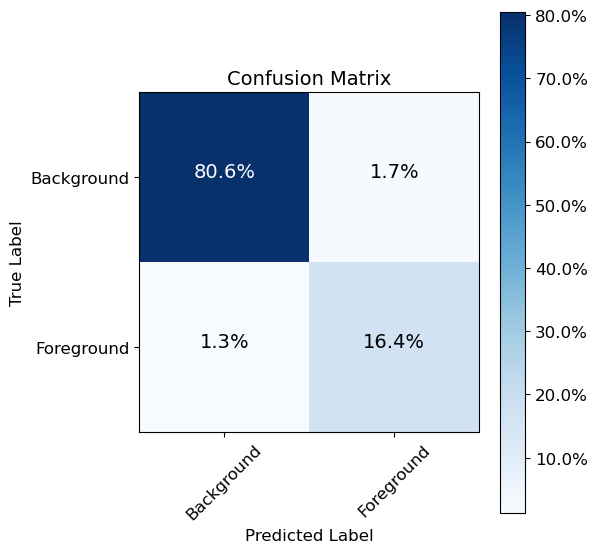

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools

all_preds_flat = all_preds.view(-1).numpy().astype(int)
all_labels_flat = all_labels.view(-1).numpy().astype(int)
cm = confusion_matrix(all_labels_flat, all_preds_flat, labels=[0, 1])

# Calculating the Dice Factor
dice_list = []
eps = 1e-6
for i in range(all_preds.shape[0]):
    pred = all_preds[i]
    label = all_labels[i]
    intersection = (pred * label).sum().item()
    dice = 2 * intersection / (pred.sum().item() + label.sum().item() + eps)
    dice_list.append(dice)
# Calculate Dice coefficient statistical indicators    
dice_list = np.array(dice_list)
avg_dice = np.mean(dice_list)
min_dice = np.min(dice_list)
max_dice = np.max(dice_list)

print("Average Dice: {:.2f}%".format(avg_dice * 100))
print("Lowest Dice: {:.2f}%".format(min_dice * 100))
print("Highest Dice: {:.2f}%".format(max_dice * 100))

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm_sum = np.sum(cm)
    cm_percentage = cm / cm_sum * 100

    plt.figure(figsize=(6,6))
    plt.imshow(cm_percentage, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    cbar = plt.colorbar(format='%.1f%%')
    cbar.ax.tick_params(labelsize=12)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)
    thresh = cm_percentage.max() / 2.
    for i, j in itertools.product(range(cm_percentage.shape[0]), range(cm_percentage.shape[1])):
        plt.text(j, i, f"{cm_percentage[i, j]:.1f}%",
                 horizontalalignment="center",
                 color="white" if cm_percentage[i, j] > thresh else "black",
                 fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes=["Background", "Foreground"])


### Visualization of model predictions

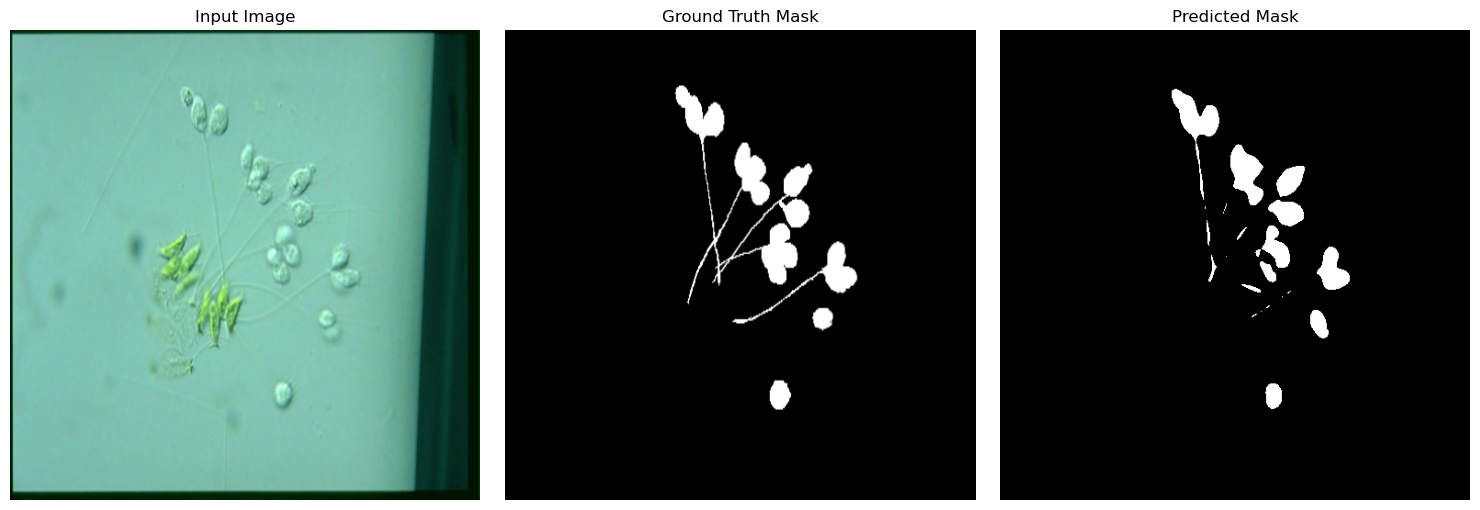

In [25]:
import random
import matplotlib.pyplot as plt
import torch
import pickle
from torchvision import transforms
with open("test_data.pkl", "rb") as f:
    test_data = pickle.load(f)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

to_tensor_resize = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

test_data_tensor = [(to_tensor_resize(img), to_tensor_resize(mask)) 
                    for img, mask in test_data]

random_index = random.randint(0, len(test_data_tensor) - 1)
image, mask = test_data_tensor[random_index]

input_image = image.unsqueeze(0).to(device)

model.to(device)
model.eval()

with torch.no_grad():
    output = model(input_image)
    pred = torch.sigmoid(output)
    pred_bin = (pred > 0.5).float().squeeze(0)

image_np = image.permute(1, 2, 0).cpu().numpy()
mask_np = mask.squeeze(0).cpu().numpy()
pred_np = pred_bin.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_np)
axes[0].set_title("Input Image")
axes[0].axis("off")

axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

axes[2].imshow(pred_np, cmap='gray')
axes[2].set_title("Predicted Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

IoU: 77.79%


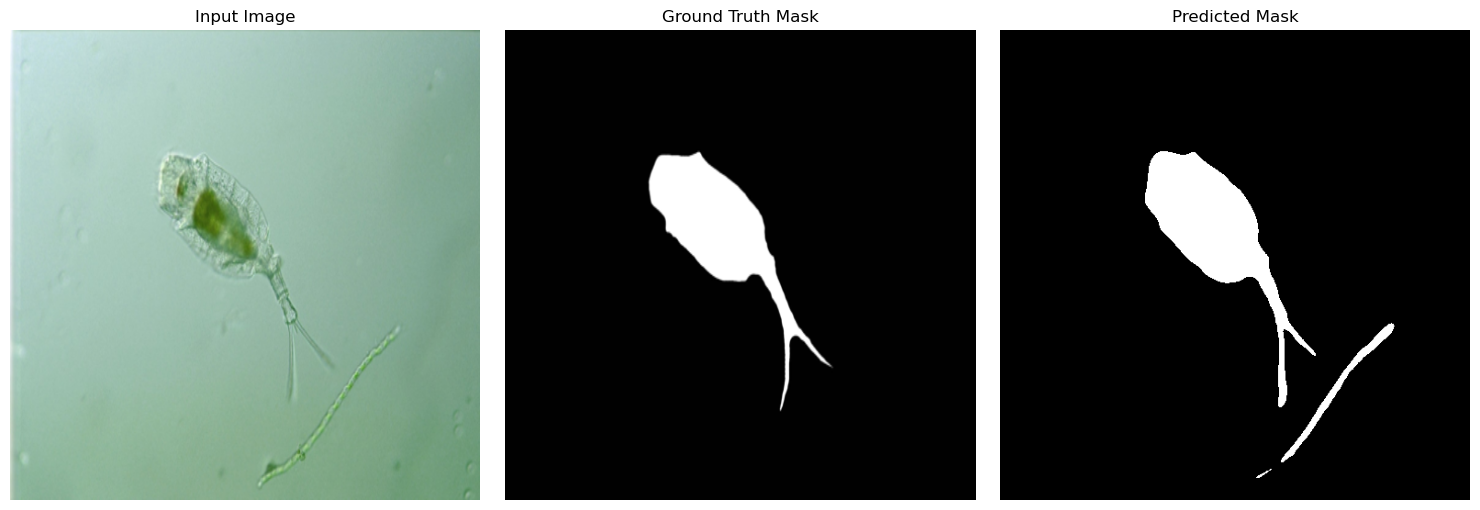

In [26]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import segmentation_models_pytorch as smp
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

to_tensor_resize = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

folder = "09"
filename = "EMDS5-g09-01.png"
orig_path = os.path.join('../../EMDS-6/EMDS5-Original', folder, filename)
gt_filename = filename.replace(".png", "-GTM.png")
gt_path = os.path.join('../../EMDS-6/EMDS5-Ground Truth', folder, gt_filename)

image = Image.open(orig_path).convert("RGB")
mask = Image.open(gt_path).convert("L")
image_tensor = to_tensor_resize(image)
mask_tensor = to_tensor_resize(mask)

input_image = image_tensor.unsqueeze(0).to(device)

model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)
model.load_state_dict(torch.load("model-denoised.pth", map_location=device, weights_only=True))
model = model.to(device)
model.eval()

with torch.no_grad():
    output = model(input_image)
    pred = torch.sigmoid(output)
    pred_bin = (pred > 0.5).float().squeeze(0)

# Computing IoU
# Put both the predicted and true masks on the CPU first.
pred_cpu = pred_bin.cpu()
mask_cpu = mask_tensor
intersection = (pred_cpu * mask_cpu).sum().item()
union = pred_cpu.sum().item() + mask_cpu.sum().item() - intersection + 1e-6
iou = intersection / union

print("IoU: {:.2f}%".format(iou * 100))

image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
mask_np = mask_tensor.squeeze(0).cpu().numpy()
pred_np = pred_bin.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_np)
axes[0].set_title("Input Image")
axes[0].axis("off")
axes[1].imshow(mask_np, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")
axes[2].imshow(pred_np, cmap="gray")
axes[2].set_title("Predicted Mask")
axes[2].axis("off")
plt.tight_layout()
plt.show()

Average IoU: 84.92%
Highest IoU: 98.66% at sample index 124
Lowest IoU: 32.86% at sample index 118


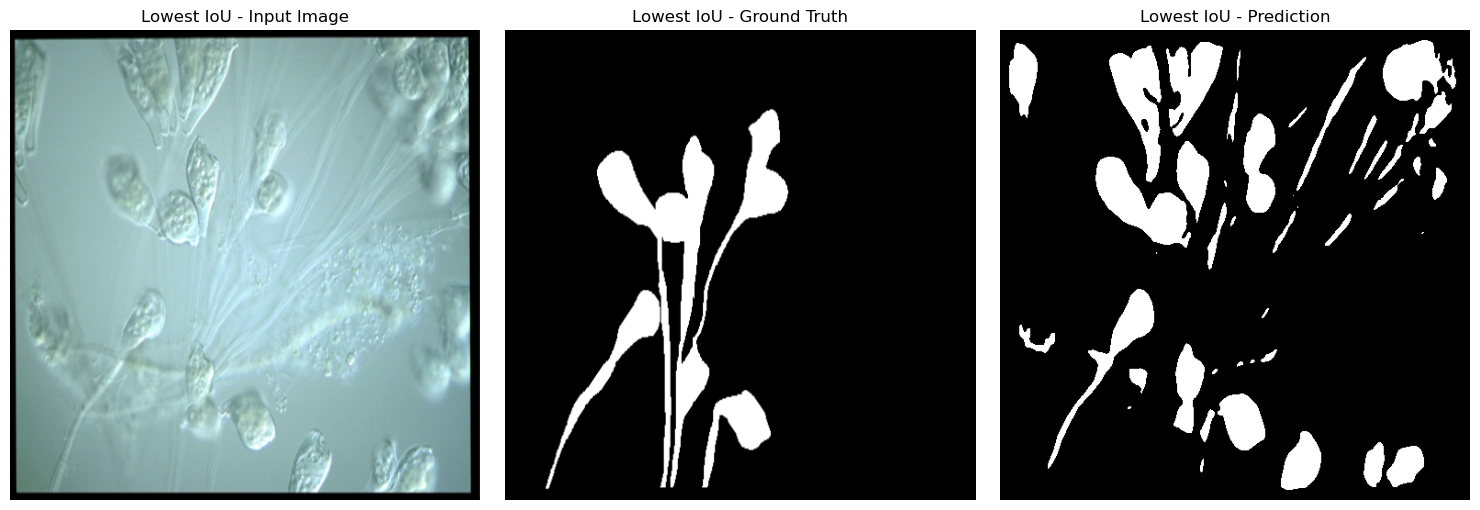

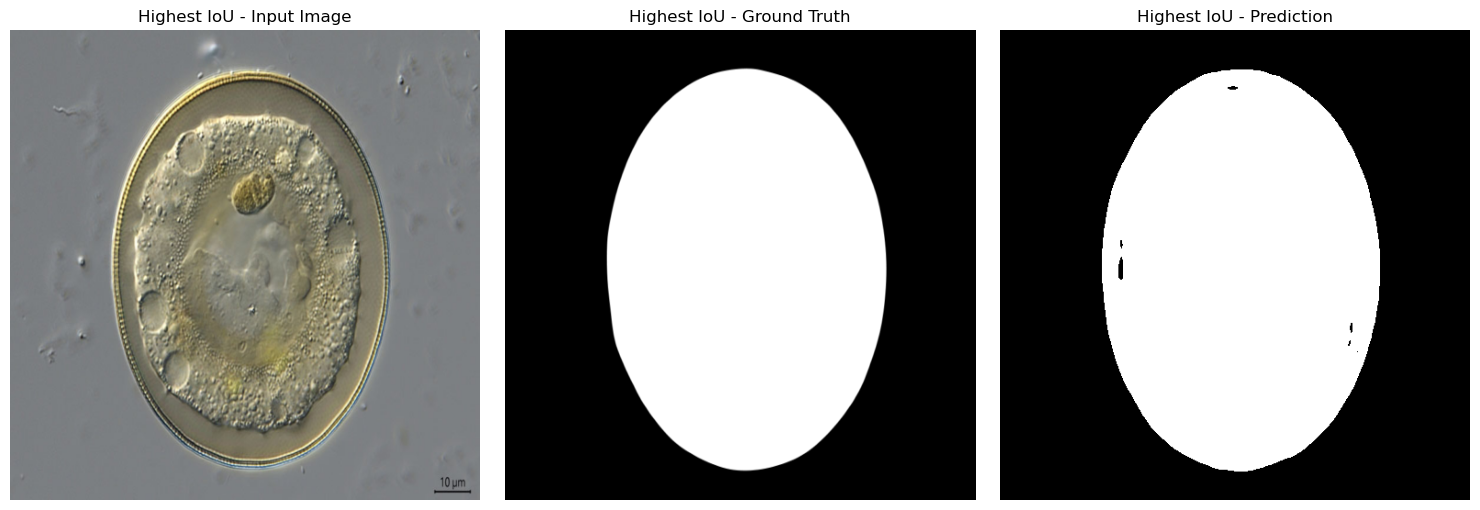

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import itertools


model.load_state_dict(torch.load("model-original.pth", weights_only=True))
model.eval()

iou_list = []
lowest_iou = 1.0
highest_iou = 0.0
lowest_sample = None 
highest_sample = None 
lowest_index = -1
highest_index = -1
sample_idx = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds_bin = (preds > 0.5).float()
        for i in range(images.size(0)):
            pred = preds_bin[i]
            mask = masks[i]
            intersection = (pred * mask).sum()
            union = pred.sum() + mask.sum() - intersection + 1e-6
            iou = (intersection / union).item()
            iou_list.append(iou)
            if iou < lowest_iou:
                lowest_iou = iou
                lowest_sample = (images[i].cpu(), masks[i].cpu(), pred.cpu())
                lowest_index = sample_idx
            if iou > highest_iou:
                highest_iou = iou
                highest_sample = (images[i].cpu(), masks[i].cpu(), pred.cpu())
                highest_index = sample_idx
            sample_idx += 1

avg_iou = np.mean(iou_list)
max_iou = np.max(iou_list)
min_iou = np.min(iou_list)

print("Average IoU: {:.2f}%".format(avg_iou * 100))
print("Highest IoU: {:.2f}% at sample index {}".format(max_iou * 100, highest_index))
print("Lowest IoU: {:.2f}% at sample index {}".format(min_iou * 100, lowest_index))

# Display lowest IoU sample (side-by-side display of input map, GT mask, and predictions)
if lowest_sample is not None:
    image_tensor, mask_tensor, pred_tensor = lowest_sample
    image_np = image_tensor.permute(1, 2, 0).numpy()
    mask_np = mask_tensor.squeeze(0).numpy()
    pred_np = pred_tensor.squeeze(0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_np)
    axes[0].set_title("Lowest IoU - Input Image")
    axes[0].axis("off")
    axes[1].imshow(mask_np, cmap="gray")
    axes[1].set_title("Lowest IoU - Ground Truth")
    axes[1].axis("off")
    axes[2].imshow(pred_np, cmap="gray")
    axes[2].set_title("Lowest IoU - Prediction")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

# Displays highest IoU sample (side-by-side display of input map, GT mask, and predictions)
if highest_sample is not None:
    image_tensor, mask_tensor, pred_tensor = highest_sample
    image_np = image_tensor.permute(1, 2, 0).numpy()
    mask_np = mask_tensor.squeeze(0).numpy()
    pred_np = pred_tensor.squeeze(0).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_np)
    axes[0].set_title("Highest IoU - Input Image")
    axes[0].axis("off")
    axes[1].imshow(mask_np, cmap="gray")
    axes[1].set_title("Highest IoU - Ground Truth")
    axes[1].axis("off")
    axes[2].imshow(pred_np, cmap="gray")
    axes[2].set_title("Highest IoU - Prediction")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()


### Calculation of multiple assessment metrics (Dice coefficient, Jaccard index and recall rate)

In [35]:
import numpy as np

eps = 1e-6

dice_list = []
jaccard_list = []
recall_list = []

for i in range(all_preds.shape[0]):
    pred = all_preds[i]
    label = all_labels[i]
    intersection = (pred * label).sum().item()
    dice = 2 * intersection / (pred.sum().item() + label.sum().item() + eps)
    jaccard = intersection / (pred.sum().item() + label.sum().item() - intersection + eps)
    recall = intersection / (label.sum().item() + eps)
    dice_list.append(dice)
    jaccard_list.append(jaccard)
    recall_list.append(recall)

dice_array = np.array(dice_list)
jaccard_array = np.array(jaccard_list)
recall_array = np.array(recall_list)

avg_dice = np.mean(dice_array)
min_dice = np.min(dice_array)
max_dice = np.max(dice_array)

avg_jaccard = np.mean(jaccard_array)
min_jaccard = np.min(jaccard_array)
max_jaccard = np.max(jaccard_array)

avg_recall = np.mean(recall_array)
min_recall = np.min(recall_array)
max_recall = np.max(recall_array)

print("Average Dice: {:.2f}%".format(avg_dice * 100))
print("Lowest Dice: {:.2f}%".format(min_dice * 100))
print("Highest Dice: {:.2f}%".format(max_dice * 100))
print()
print("Average Jaccard (IoU): {:.2f}%".format(avg_jaccard * 100))
print("Lowest Jaccard (IoU): {:.2f}%".format(min_jaccard * 100))
print("Highest Jaccard (IoU): {:.2f}%".format(max_jaccard * 100))
print()
print("Average Recall: {:.2f}%".format(avg_recall * 100))
print("Lowest Recall: {:.2f}%".format(min_recall * 100))
print("Highest Recall: {:.2f}%".format(max_recall * 100))


Average Dice: 91.22%
Lowest Dice: 49.46%
Highest Dice: 99.33%

Average Jaccard (IoU): 84.92%
Lowest Jaccard (IoU): 32.86%
Highest Jaccard (IoU): 98.66%

Average Recall: 90.62%
Lowest Recall: 45.11%
Highest Recall: 99.92%
